# Metrics

## Loading Packages

In [12]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
import uuid

import matplotlib.pyplot as plt

## Loading Results

In [13]:
# List of slice names
slices = ['ATAC', 'H3K4me3', 'H3K27ac', 'H3K27me3']
# List of methods
methods = ['SpatialCOC', 'COSMOS', 'SpatialGlue', 'MultiVI', 'MultiMAP', 'STAGATE', 'SpaGCN', 'Modality1', 'Modality2']
# Create a dictionary to store data for each slice
adata_results = {}

# Load data and store it
for slice_name in slices:
    path = f'../../Mouse_Brain_{slice_name}.h5ad'
    result = sc.read_h5ad(path)  # Assuming 'sc' is the Scanpy library
    adata_results[slice_name] = result

In [14]:
adata_results

{'ATAC': AnnData object with n_obs × n_vars = 9196 × 0
     obs: 'SpatialCOC', 'SpatialGlue', 'SpaGCN', 'STAGATE', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'COSMOS'
     obsm: 'COSMOS', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'STAGATE', 'SpatialCOC', 'SpatialGlue', 'spatial',
 'H3K4me3': AnnData object with n_obs × n_vars = 9513 × 0
     obs: 'SpatialCOC', 'SpatialGlue', 'SpaGCN', 'STAGATE', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'COSMOS'
     obsm: 'COSMOS', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'STAGATE', 'SpatialCOC', 'SpatialGlue', 'spatial',
 'H3K27ac': AnnData object with n_obs × n_vars = 9323 × 0
     obs: 'SpatialCOC', 'SpatialGlue', 'SpaGCN', 'STAGATE', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'COSMOS'
     obsm: 'COSMOS', 'Modality1', 'Modality2', 'MultiMAP', 'MultiVI', 'STAGATE', 'SpatialCOC', 'SpatialGlue', 'spatial',
 'H3K27me3': AnnData object with n_obs × n_vars = 9732 × 0
     obs: 'SpatialCOC', 'SpatialGlue', 'SpaGCN', 'STA

## Calculating Moran's I Score

In [ ]:
# Dictionary to store Moran's I scores for each slice
moran_scores = {}

# Iterate over each slice and its corresponding data
for slice_name, adata in adata_results.items():
    print(slice_name)
    # Construct the spatial graph (adjust parameters based on the data type)
    sq.gr.spatial_neighbors(adata, coord_type='grid')  # or 'generic'
    moran_scores[slice_name] = {}
    
    # Iterate over each method
    for method in methods:
        # Skip if the method is not present in the observation columns
        if method not in adata.obs.columns:
            continue
        
        # Get the cluster information for the current method
        cluster = adata.obs[method]
        # Get unique categories, ignoring NaN values
        categories = cluster.dropna().unique()
        moran_scores[slice_name][method] = {}
        
        # Iterate over each category
        for category in categories:
            # Create a mask for the current category
            mask = cluster == category
            # Generate a unique temporary column name
            temp_col = f"temp_{uuid.uuid4().hex}"
            
            try:
                # Add the mask as a new column in the observation DataFrame
                adata.obs[temp_col] = mask.astype(int)
                # Calculate Moran's I spatial autocorrelation
                sq.gr.spatial_autocorr(
                    adata,
                    mode="moran",
                    n_perms=100,  # Number of permutations for significance testing
                    attr="obs",  # Attribute type (observations)
                    genes=[temp_col],  # Use the temporary column name
                    n_jobs=4,  # Number of jobs to run in parallel
                    seed=2024  # Random seed for reproducibility
                )
                # Retrieve the Moran's I score from the results
                score = adata.uns['moranI'].loc[temp_col, 'I']
                # Store the score in the dictionary
                moran_scores[slice_name][method][category] = score
            finally:
                # Clean up: Remove the temporary column
                if temp_col in adata.obs:
                    del adata.obs[temp_col]

## Storing the Results as an Excel

In [16]:
# Function to convert category keys to integers and sort them in ascending order
def convert_and_sort_categories(moran_scores):
    for slice_name, methods in moran_scores.items():
        for method, categories in methods.items():
            # Convert category keys to integers and sort them
            sorted_categories = {
                int(k): v for k, v in sorted(categories.items(), key=lambda x: int(x[0]))
            }
            moran_scores[slice_name][method] = sorted_categories
    return moran_scores

# Convert category keys to integers and sort them
moran_scores = convert_and_sort_categories(moran_scores)

# Create an Excel file
with pd.ExcelWriter("moran_scores_output.xlsx") as writer:
    # Dictionary to store the average values for all slices
    all_averages = {}
    
    for slice_name, methods in moran_scores.items():
        # Convert to DataFrame (each row represents a method, column names are categories)
        df = pd.DataFrame.from_dict(methods, orient="index")
        
        # Calculate the mean value for each row
        averages = df.mean(axis=1)
        all_averages[slice_name] = averages
        
        # Clean the sheet name (Excel limit: max 31 characters, no special symbols)
        sheet_name = str(slice_name)\
            .replace(":", "_").replace("/", "_")[:31]
        
        # Write to Excel (missing values are represented as empty strings)
        df.to_excel(
            writer,
            sheet_name=sheet_name,
            na_rep="",
            index_label="Method"
        )
    
    # Store the average values of all slices in a new sheet
    averages_df = pd.DataFrame.from_dict(all_averages, orient="index")
    
    # Transpose the averages DataFrame so that each row corresponds to a slice and each column corresponds to a method's average value
    averages_df = averages_df.transpose()
    
    # Write the averages sheet
    averages_df.to_excel(
        writer,
        sheet_name="Averages",
        index_label="Method"
    )

## Visualizing

ATAC best_median = 0.2847066542959066
Drawn & saved Moran_Score for ATAC
H3K4me3 best_median = 0.47457344592983886
Drawn & saved Moran_Score for H3K4me3
H3K27ac best_median = 0.32334005810037175
Drawn & saved Moran_Score for H3K27ac
H3K27me3 best_median = 0.557823553312141
Drawn & saved Moran_Score for H3K27me3
Averages best_median = 0.3352283476530922
Drawn & saved Moran_Score for Averages


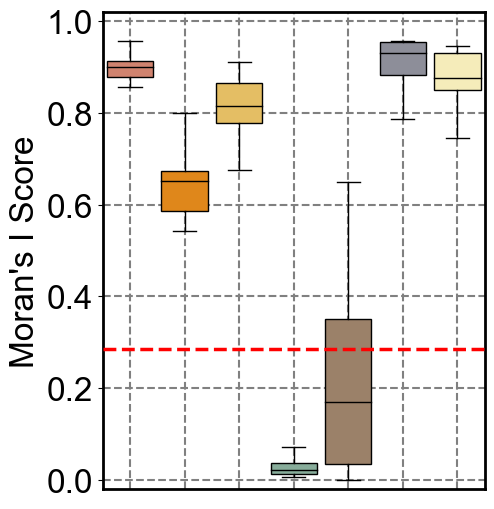

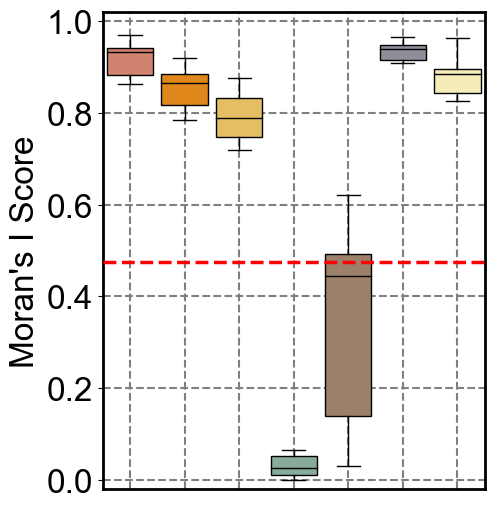

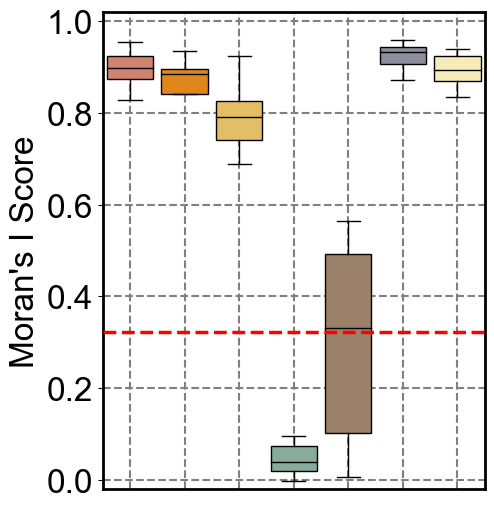

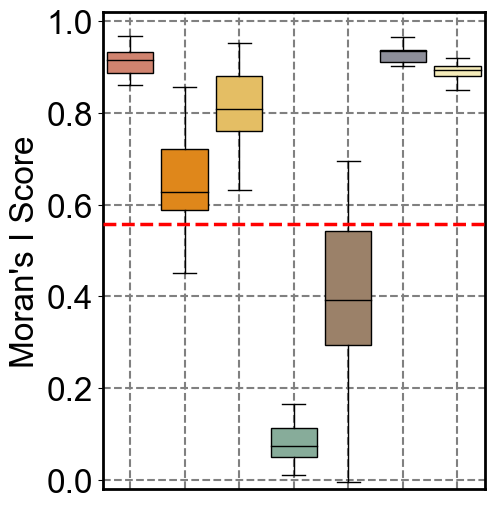

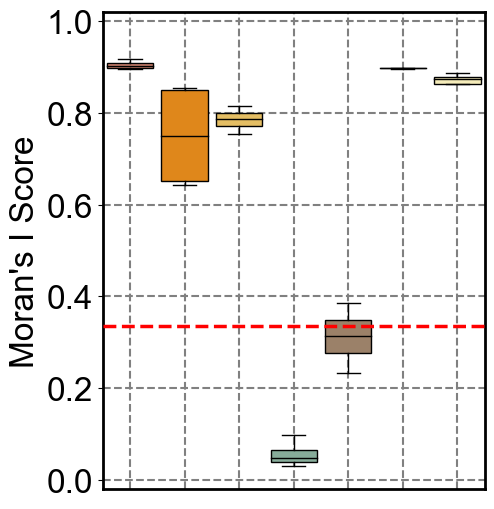

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

methods = ['SpatialCOC', 'COSMOS', 'SpatialGlue', 'MultiVI', 'MultiMAP', 'STAGATE', 'SpaGCN']
colors  = ['#D0836F', '#df871b', '#E4BE64', '#87AC9A', '#9B8169', '#8D8E99', '#F5ECBA']

y_min, y_max = -0.02, 1.02
fontsize = 24
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['font.size'] = fontsize

file_path = 'moran_scores_output.xlsx'
xls = pd.ExcelFile(file_path)
slices = xls.sheet_names

def extract_valid_values(df, method_name):
    rows = df.loc[df['Method'] == method_name].drop(columns=['Method'])
    vals = []
    for col in rows.columns:
        for v in rows[col]:
            if pd.notna(v) and str(v).strip() != '':
                try:
                    vals.append(float(v))
                except ValueError:
                    continue
    return np.array(vals)

for slice_name in slices:
    df = pd.read_excel(xls, sheet_name=slice_name)

    data = []
    for method in methods:
        vals = extract_valid_values(df, method)
        if vals.size > 0:
            data.append(vals)

    if not data:
        print(f'No valid data for {slice_name}, skipping...')
        continue

    # ---- Modality1/2  median ----
    modality1_data = extract_valid_values(df, 'Modality1')
    modality2_data = extract_valid_values(df, 'Modality2')
    median_modality1 = np.median(modality1_data) if modality1_data.size else None
    median_modality2 = np.median(modality2_data) if modality2_data.size else None

    if median_modality1 is not None and median_modality2 is not None:
        best_median = max(median_modality1, median_modality2)   # 按你原逻辑
    else:
        best_median = None
    print(slice_name, 'best_median =', best_median)
    # ---- Plot ----
    plt.figure(figsize=(5, 5))
    bp = plt.boxplot(data, patch_artist=True,
                     boxprops=dict(linewidth=1, edgecolor='black'),
                     medianprops=dict(linewidth=1, color='black'),
                     whiskerprops=dict(linewidth=1, color='black'),
                     capprops=dict(linewidth=1, color='black'),
                     widths=0.85, showfliers=False)

    for patch, color in zip(bp['boxes'], colors[:len(data)]):
        patch.set_facecolor(color)

    plt.xticks([])
    plt.ylim(y_min, y_max)
    plt.ylabel("Moran's I Score", fontsize=fontsize)
    for spine in plt.gca().spines.values():
        spine.set_linewidth(2)
    plt.grid(axis='y', color='gray', linestyle='--', alpha=1, linewidth=1.5, zorder=-10)
    for x in range(1, len(data) + 1):
        plt.axvline(x=x, color='gray', linestyle='--', alpha=1, linewidth=1.5, zorder=-10)
    if best_median is not None:
        plt.axhline(y=best_median, color='#FF0000', linestyle='--', linewidth=2.5, zorder=10)

    plt.tight_layout(pad=0.1, rect=[0, 0, 1, 1])

    # ---- Save ----
    save_dir = './' if slice_name == 'Averages' else f'./{slice_name}/'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(save_dir + 'Moran_Score.png', dpi=500)
    plt.savefig(save_dir + 'Moran_Score.eps')

    print(f'Drawn & saved Moran_Score for {slice_name}')